In [40]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
# Begining of the script used to test the THM prototype class.

In [41]:
case_name = "PSBT BenchMark Ex1 12223 MPHYS"
#User choice:
solveConduction = False
plot_at_z1 = []

########## Thermal hydraulics parameters ##########
## Geometric parameters
canalType = "square"
waterRadius = 0.0133409 # m
fuelRadius = 0.00271155 # m : fuel rod radius
#fuelRadius = 0.00208012
gapRadius = fuelRadius + 0.0000001  # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
cladRadius =  0.0047498 # m : clad external radius
#waterRadius = 0.012044
#cladRadius = 0.00510157
height = 1.555 # m : height : active core height in BWRX-300 SMR

## Fluid parameters
pOutlet = 14719781.65 # Pa
tInlet = 592.75 #K
u_inlet = 4.467092221 #m/s
pressureDrop = 186737 #Pa/m
falsePInlet = pOutlet + height * pressureDrop
rhoInlet = IAPWS97(T = tInlet, P = falsePInlet*10**(-6)).rho #kg/m3
flowArea = waterRadius ** 2 - np.pi * cladRadius ** 2
qFlow = u_inlet * rhoInlet * flowArea # kg/m^2/s

## Meshing parameters:
If = 8
I1 = 3
Iz1 = 70 # number of control volumes in the axial direction

## Thermalhydraulics correlation
voidFractionCorrel = "EPRIvoidModel"    #choice between 'EPRIvoidModel' and 'GEramp' and 'modBestion' and 'HEM1'
frfaccorel = "blasius"                #choice between 'Churchill' and 'blasius' 'base'
P2Pcorel = "lockhartMartinelli"                       #choice between 'HEM1' and 'HEM2' and 'MNmodel'
numericalMethod = 'BiCG'            #choice between 'BiCG', 'BiCGStab', 'GaussSiedel' and 'FVM'

############ Nuclear Parameters ###########
## Fission parameters
qFiss = 2200000000 # W/m3
#qFiss = 1943301220 # W/m3
## Material parameters
kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
Hgap = 10000
kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
# k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity
########## Algorithm parameters ###########
nIter = 1000
tol = 1e-4

Qfiss1 = [1.594869022550987601e+08,
3.013561651525602341e+08,
4.315987543228657246e+08,
5.551952783907946348e+08,
6.745869080931930542e+08,
7.909117819301559925e+08,
9.046392151319634914e+08,
1.015899814243501186e+09,
1.124654028557870865e+09,
1.230779934843279839e+09,
1.334114572292357206e+09,
1.434482847249299288e+09,
1.531706335472456932e+09,
1.625608396962606907e+09,
1.716017625498263597e+09,
1.802766897039750338e+09,
1.885707405769541264e+09,
1.964692011163025618e+09,
2.039585110796541929e+09,
2.110258239216102839e+09,
2.176605412422180653e+09,
2.238560256596883297e+09,
2.295973371175192833e+09,
2.348761491511007309e+09,
2.396837784473403454e+09,
2.440137303638415337e+09,
2.478595816279062271e+09,
2.512159557223824501e+09,
2.540779995079010963e+09,
2.564421444996292114e+09,
2.583050363218200684e+09,
2.596650572613531590e+09,
2.605193763202597618e+09,
2.608672322217755318e+09,
2.607081491679239750e+09,
2.600414848314313889e+09,
2.588663114062449932e+09,
2.571813204479260445e+09,
2.549819442958845615e+09,
2.522568113784566879e+09,
2.489808947220127583e+09,
2.451016900197106838e+09,
2.405148071952384472e+09,
2.350131313888881683e+09,
2.279856666275661469e+09,
2.202476689562075138e+09,
2.123999998509807587e+09,
2.044798429238484859e+09,
1.964826661990717411e+09,
1.884276205452540398e+09,
1.803160144068341017e+09,
1.721210722526154041e+09,
1.638514892906425238e+09,
1.555117737067494631e+09,
1.471076350766739130e+09,
1.386442001236242294e+09,
1.301266550455575943e+09,
1.215601622505323410e+09,
1.129479571647970438e+09,
1.042940127014667511e+09,
9.560065432315443754e+08,
8.686876820359679461e+08,
7.809661173269932270e+08,
6.927409799333423376e+08,
6.039016468251940012e+08,
5.141965992965724468e+08,
4.230966310467516184e+08,
3.296286459991601110e+08,
2.320185124443531632e+08,
1.270411824771733582e+08]

case0 = Version5_THM_prototype(case_name, canalType,
                waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

""""#cladRadius =  0.0054996/2
case1 = Version5_THM_prototype(case_name, canalType,
                waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)
frfaccorel = "Churchill"
case1 = Version5_THM_prototype(case_name, canalType,
                waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

frfaccorel = "base"
case2 = Version5_THM_prototype(case_name, canalType,
                waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

P2Pcorel = "HEM2"
frfaccorel = "blasius"
case3 = Version5_THM_prototype(case_name, canalType,
                waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)


frfaccorel = "Churchill"
case4 = Version5_THM_prototype(case_name, canalType,
                waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

frfaccorel = "base"
case5 = Version5_THM_prototype(case_name, canalType,
                waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

P2Pcorel = "lockhartMartinelli"
frfaccorel = "blasius"
case6 = Version5_THM_prototype(case_name, canalType,
                waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)


frfaccorel = "Churchill"
case7 = Version5_THM_prototype(case_name, canalType,
                waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

frfaccorel = "base"
case8 = Version5_THM_prototype(case_name, canalType,
                waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod) """

caseMerge = [case0]#, case1, case2, case3, case4, case5, case6, case7, case8]


$$$---------- THM: prototype, case treated : PSBT BenchMark Ex1 12223 MPHYS.
$$$---------- THM: prototype, steady state case.
$$---------- Calling DFM class.
Setting up heat convection solution along the axial dimension. zmax = 1.555 m with 70 axial elements.
self.I_z: 70
self.qFlow: 0.32526840090529774
self.pOutlet: 14719781.65
self.Lf: 1.555
self.r_f: 0.00271155
self.clad_r: 0.0047498
self.r_w: 0.0133409
self.Dz: 0.022214285714285714
self.dt: 0
Courant number: 0.0
Numerical Method BiCG
Velocity at the inlet:  4.467092221
cote: 0.0133409
cladRadius: 0.0047498
Dh: 0.014355160325313157
Hydraulic diameter: [0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.014355160325313157, 0.01435516032

In [42]:

class GFPlotter():
    def __init__(self, caseList, directory_path, case_name):
        self.case_name = f'{case_name}\\'

        self.caseList = caseList
        self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height

        self.data_dict_list = []
        self.data_dict = self.read_files_in_directory()
        self.allow_space()

        self.struture_fraction = 1 - (self.alpha_liquid[0] + self.alpha_vapour[0])

        self.calculateFields()
        self.createZ()

    def plotCase(self):
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        labelTitle = 'DFM'
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)

        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GenFoam: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)

        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"DFM {self.caseList[i].convection_sol.frfaccorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p_rgh, label="GenFoam P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GenFoam")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def createZ(self):
        self.zList = np.linspace(0, self.height, len(self.alpha_liquid))

    def read_files_in_directory(self):
        data_dict = {}
        print(f"Reading files in directory: {self.directory_path}")
        # Parcourt tous les fichiers du dossier
        for filename in os.listdir(self.directory_path):
            file_path = os.path.join(self.directory_path, filename)
            print(f"Reading file: {file_path}")
            # Vérifie que c'est bien un fichier
            if os.path.isfile(file_path):

                with open(file_path, 'r') as file:
                    content = file.read()
                    
                    # Trouve la première parenthèse ouvrante et fermante
                    start = content.find('(')
                    end = content.find(')', start)
                    #end = start + 74
                    if start != -1 and end != -1:
                        # Extrait les données entre les parenthèses
                        data_str = content[start+1:end].strip()
                        # Divise les lignes en liste de chaînes
                        data_lines = data_str.splitlines()
                        if len(data_lines) != 1:
                            float_list = [float(item) for item in data_lines]
                            data_dict[filename] = float_list

                    if len(data_lines) == 1:
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(';', start)
                        #end = start
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            data_lines.pop()
                            x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                            for i in range(len(data_lines)):
                                a = values = data_lines[i].strip("()").split()
                                x[i] = float(a[0])
                                y[i] = float(a[1])
                                z[i] = float(a[2])
                            data_dict[fr'{filename}_x'] = x
                            data_dict[fr'{filename}_y'] = y
                            data_dict[fr'{filename}_z'] = z
        
        return data_dict
    
    def allow_space(self):
        self.alpha_liquid = np.array(self.data_dict['alpha.liquid'])
        self.alpha_vapour = np.array(self.data_dict['alpha.vapour'])
        #self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = np.array(self.data_dict['alphaPhi.liquid']+ [self.data_dict['alphaPhi.liquid'][-1]])
        self.alphaPhi_vapour = np.array(self.data_dict['alphaPhi.vapour']+ [self.data_dict['alphaPhi.vapour'][-1]])
        self.alphaRhoMagU_liquid = np.array(self.data_dict['alphaRhoMagU.liquid'])#+ [self.data_dict['alphaRhoMagU.liquid'][-1]])
        self.alphaRhoMagU_vapour = np.array(self.data_dict['alphaRhoMagU.vapour'])#+ [self.data_dict['alphaRhoMagU.vapour'][-1]])
        self.alphaRhoPhi_liquid = np.array(self.data_dict['alphaRhoPhi.liquid']+ [self.data_dict['alphaRhoPhi.liquid'][-1]])
        self.alphaRhoPhi_vapour = np.array(self.data_dict['alphaRhoPhi.vapour']+ [self.data_dict['alphaRhoPhi.vapour'][-1]])
        self.areaDensity_interface = np.array(self.data_dict['areaDensity.interface'])
        self.dgdt_liquid = np.array(self.data_dict['dgdt.liquid'])
        self.dgdt_vapour = np.array(self.data_dict['dgdt.vapour'])
        self.dmdt_vapour = np.array(self.data_dict['dmdt.liquid.vapour'])
        self.heatFlux_structure = np.array(self.data_dict['heatFlux.structure'])
        self.htc_liquid_interface = np.array(self.data_dict['htc.liquid.interface'])
        self.htc_liquid_structure = np.array(self.data_dict['htc.liquid.structure'])
        self.p = np.array(self.data_dict['p'])
        self.p_rgh = np.array(self.data_dict['p_rgh'])
        self.Re_liquid_structure = np.array(self.data_dict['Re.liquid.structure'])
        #self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = np.array(self.data_dict['Re.liquid.vapour'])
        self.T_fixedPower = np.array(self.data_dict['T.fixedPower'])
        self.T_liquid = np.array(self.data_dict['T.liquid'])
        self.T_vapour = np.array(self.data_dict['T.vapour'])
        self.U_liquid_x = np.array(self.data_dict['U.liquid_x'])
        self.U_liquid_y = np.array(self.data_dict['U.liquid_y'])
        self.U_liquid_z = np.array(self.data_dict['U.liquid_z'])
        self.U_vapour_x = np.array(self.data_dict['U.vapour_x'])
        self.U_vapour_y = np.array(self.data_dict['U.vapour_y'])
        self.U_vapour_z = np.array(self.data_dict['U.vapour_z'])

    def calculateFields(self):
        self.alpha_vapour = self.alpha_vapour/(1-self.struture_fraction)
        self.alpha_liquid = self.alpha_liquid/(1-self.struture_fraction)
        self.U_liquid = np.sqrt(self.U_liquid_x**2 + self.U_liquid_y**2 + self.U_liquid_z**2)
        self.U_vapour = np.sqrt(self.U_vapour_x**2 + self.U_vapour_y**2 + self.U_vapour_z**2)
        self.U_mixture = (1-self.alpha_vapour) * self.U_liquid + self.alpha_vapour * self.U_vapour

        self.rho_liquid  = self.alphaRhoPhi_liquid/(self.alphaPhi_liquid)
        self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)
        for i in range(len(self.rho_vapour)):
            if np.isnan(self.rho_vapour[i]):
                self.rho_vapour[i] = 0
            if np.isnan(self.rho_liquid[i]):
                self.rho_liquid[i] = 0
        print(f"rho_liquid GeN-Foam: {self.rho_liquid}")
        print(f"rho_vapour GeN-Foam: {self.rho_vapour}")
        self.rho_mixture = self.rho_liquid + self.rho_vapour

        self.T_mixture = (1-self.alpha_vapour) * self.T_liquid + self.alpha_vapour * self.T_vapour

    def plotComparison(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        if len(self.caseList) == 1:
            labelTitle = 'DFM'
        labelTitle = 'DFM'
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.step(self.zList, self.T_liquid, label="GenFoam T.liquid")
        ax1.step(self.zList, self.T_vapour, label="GenFoam T.vapour")
        ax1.step(self.zList, self.T_mixture, label="GenFoam T.mixture")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)
        ax2.step(self.zList, self.alpha_vapour, label="GenFoam")
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix GeN-Foam: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)
        ax3.plot(self.zList, self.rho_mixture, label="GenFoam")
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.plot(self.zList, self.rho_liquid, label="GenFoam")
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.plot(self.zList, self.rho_vapour, label="GenFoam")
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            labelTitle = f"DFM {self.caseList[i].convection_sol.frfaccorel} {self.caseList[i].convection_sol.P2Pcorel}"
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p, label="GenFoam")
        ax4.step(self.zList, self.p_rgh, label="GenFoam P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.step(self.zList, self.U_liquid, label="GenFoam")
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.step(self.zList, self.U_vapour, label="GenFoam")
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.step(self.zList, self.U_mixture, label="GenFoam")
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.step(self.zList, self.Re_liquid_structure, label="GenFoam")
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GenFoam")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def computeErrors(self):
        self.error_T_abs = []
        self.error_T_rel = []
        self.error_p_abs = []
        self.error_p_rel = []
        self.error_rho_abs = []
        self.error_rho_rel = []
        self.error_U_abs = []
        self.error_U_rel = []
        self.error_Re_abs = []
        self.error_Re_rel = []
        self.error_eps_abs = []
        self.error_eps_rel = []

        for i in range(len(self.caseList)):
            self.error_T_abs.append((self.T_mixture - self.caseList[i].convection_sol.T_water))
            self.error_T_rel.append(100*self.error_T_abs[-1]/(self.T_mixture))
            self.error_p_abs.append((self.p - self.caseList[i].convection_sol.P[-1]))
            self.error_p_rel.append(100*self.error_p_abs[-1]/(self.p))
            self.error_rho_abs.append(self.rho_mixture - self.caseList[i].convection_sol.rho[-1])
            self.error_rho_rel.append(100*self.error_rho_abs[-1]/(self.rho_mixture))
            self.error_U_abs.append((self.U_mixture - self.caseList[i].convection_sol.U[-1]))
            self.error_U_rel.append(100*self.error_U_abs[-1]/(self.U_mixture))
            self.error_Re_abs.append((self.Re_liquid_structure - self.caseList[i].convection_sol.Rel))
            self.error_Re_rel.append(100*self.error_Re_abs[-1]/(self.Re_liquid_structure))
            self.error_eps_abs.append((self.alpha_vapour - self.caseList[i].convection_sol.voidFraction[-1]))
            self.error_eps_rel.append(self.error_eps_abs[-1]/(self.alpha_vapour))

            

    def plotErrorsPressure(self):
        fig, ax = plt.subplots()
        for i in range(len(self.caseList)):
            print(self.error_p_abs)
            ax.step(self.caseList[i].convection_sol.z_mesh, self.error_p_abs[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax.set_xlabel("Axial position in m")
        ax.set_ylabel("Absolute error in Pa")
        ax.set_title("Absolute error in pressure")
        ax.grid()
        ax.legend(loc="best")
        fig.savefig(rf'result\{self.case_name}\error_p_abs.png', bbox_inches='tight')

        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.error_p_rel[i], label=f" {self.caseList[i].convection_sol.frfaccorel} , {self.caseList[i].convection_sol.P2Pcorel}")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Relative error in %")
        ax1.set_title("Relative error in pressure")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\error_p_rel.png', bbox_inches='tight')

        plt.show()

        for i in range(len(self.caseList)):
            print(f"Mean relative error in pressure: {np.mean(self.error_p_rel[i])}, max relative error in pressure {np.max(self.error_p_rel[i])} for {self.caseList[i].convection_sol.frfaccorel}, {self.caseList[i].convection_sol.P2Pcorel}")


Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\PSBT_MPHYS_Q1
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\PSBT_MPHYS_Q1\alpha.liquid
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\PSBT_MPHYS_Q1\alpha.passiveStructure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\PSBT_MPHYS_Q1\alpha.powerModel
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\PSBT_MPHYS_Q1\alpha.structure
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\PSBT_MPHYS_Q1\alpha.vapour
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\PSBT_MPHYS_Q1\alphaPhi.liquid
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\ther

C:\Users\cleme\AppData\Local\Temp\ipykernel_16352\1505888548.py:264: RuntimeWarning: invalid value encountered in divide
  self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)


rho_mix GeN-Foam: [678.30744443 678.09630057 677.79469221 677.40568834 676.93382552
 676.37804136 675.74156424 675.02625586 674.23121983 673.35981827
 672.41265014 671.39314134 670.30402657 669.14188528 667.91366492
 666.6201146  665.26474579 663.85038747 662.3778136  660.84986043
 659.27135571 657.64643192 655.9744551  654.26084082 704.53491557
 650.72793832 648.91183962 647.07101919 645.20797098 643.32559702
 641.42953126 639.52248945 637.60993021 635.69313446 685.85743818
 684.09734066 682.42651984 680.83526802 679.32103907 677.88538592
 676.52075437 675.23112279 674.0123186  672.86387505 671.78641261
 670.78162611 669.84451656 668.97690874 668.1725888  667.43535053
 666.75966099 666.14073055 665.58062901 665.07256853 664.61332357
 664.20468623 663.83914285 663.51415709 663.23881213 663.00525705
 662.80284158 662.62463227 662.46934874 662.33431102 662.2179874
 662.11576492 662.03036556 661.95439321 661.89403964 661.89403964]


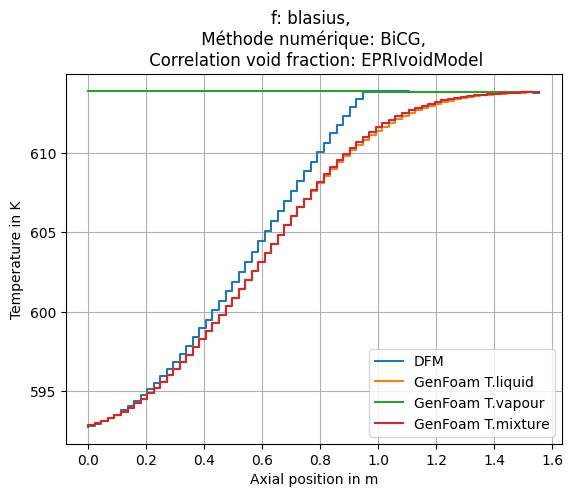

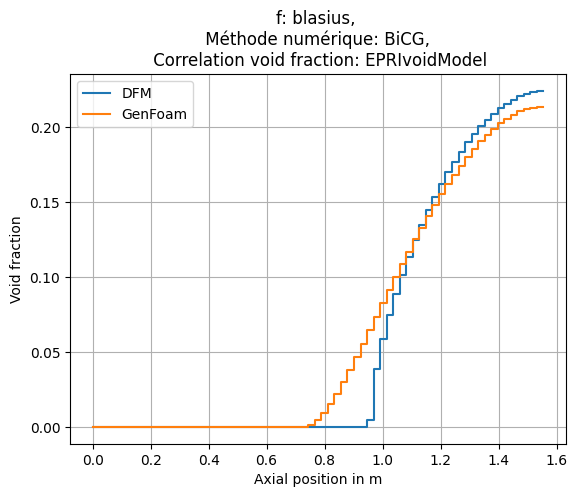

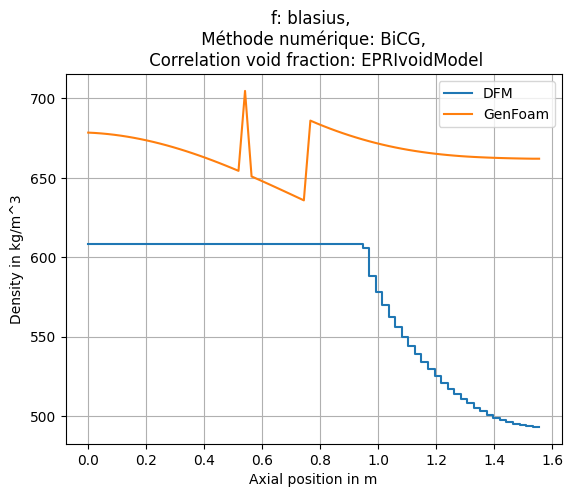

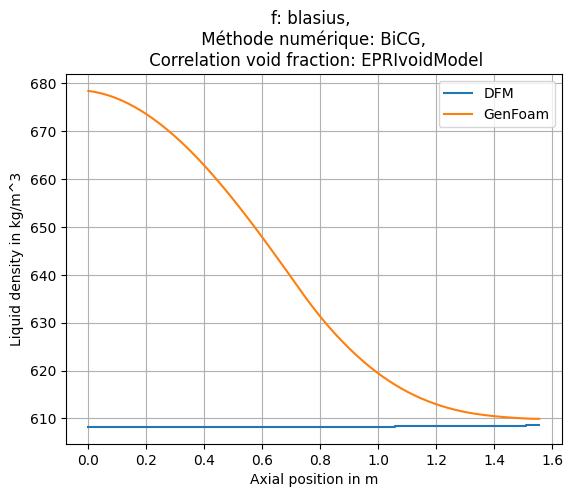

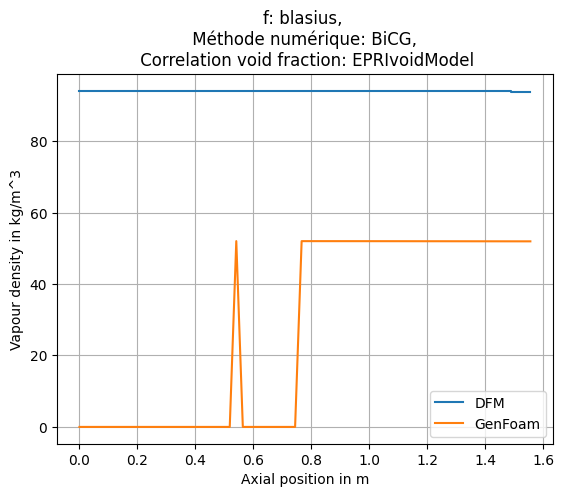

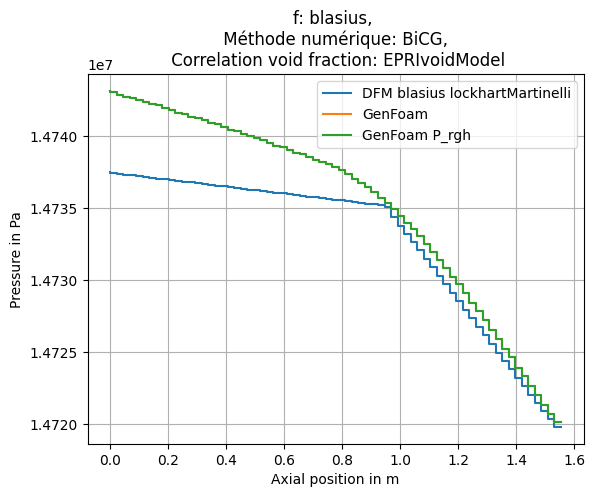

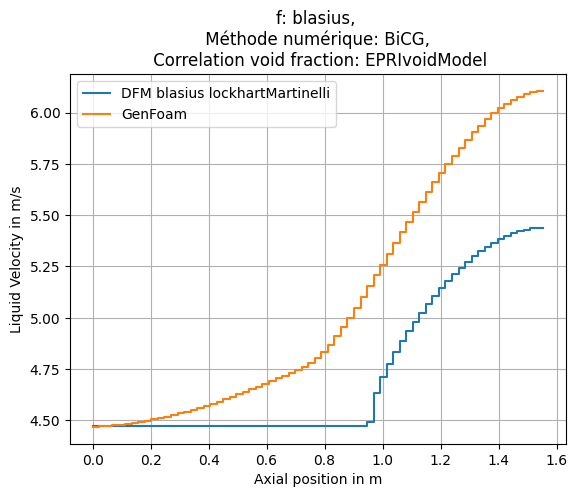

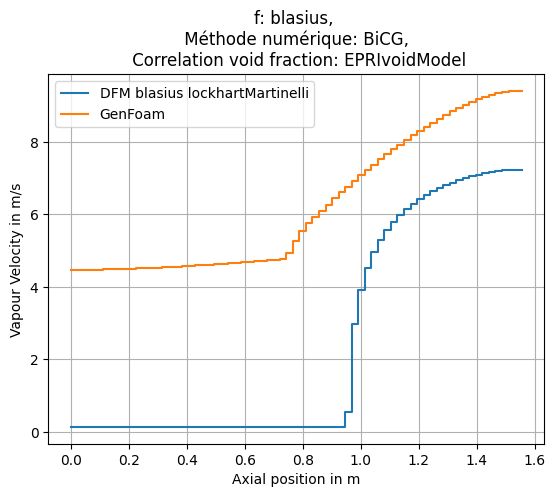

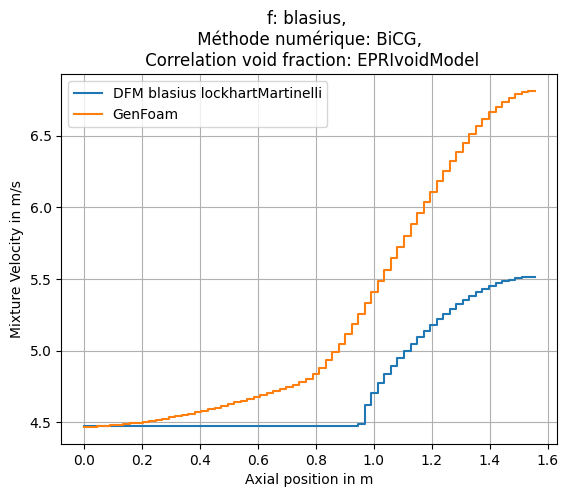

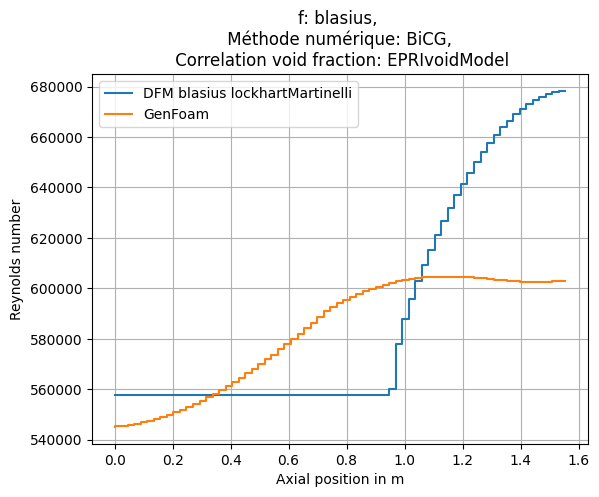

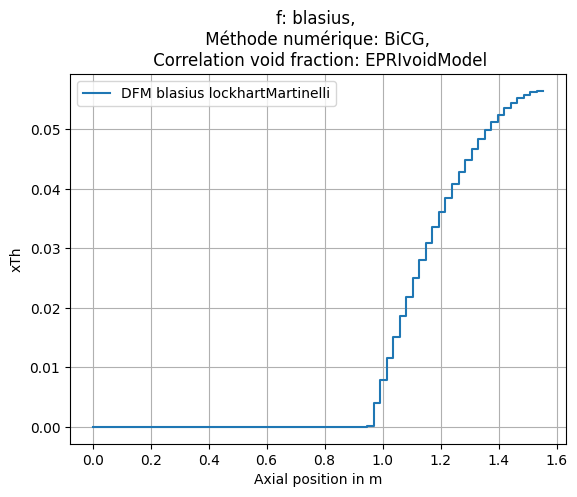

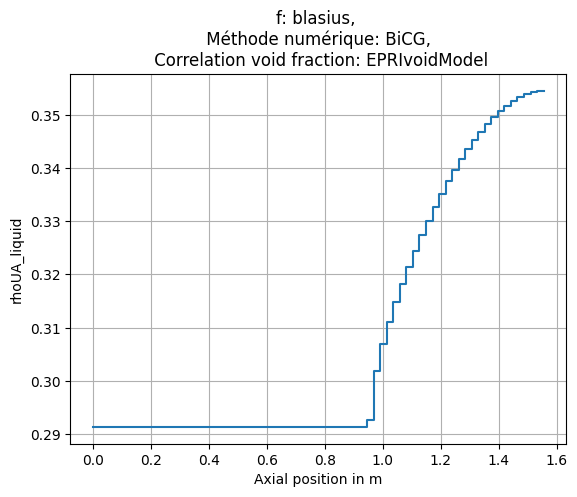

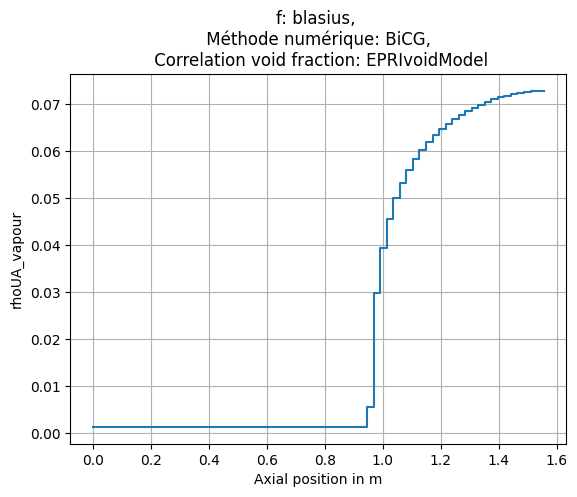

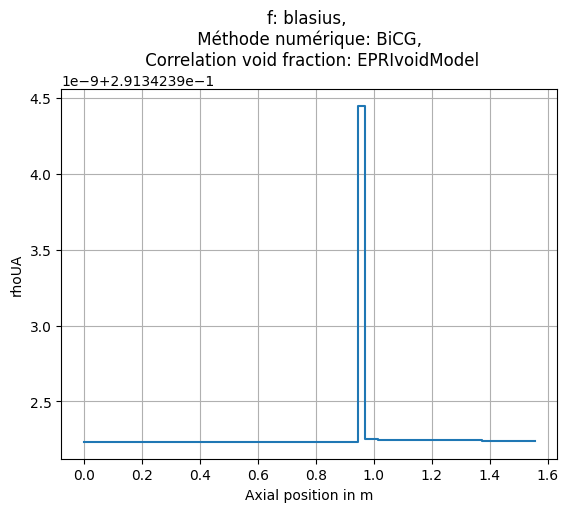

C:\Users\cleme\AppData\Local\Temp\ipykernel_16352\1505888548.py:470: RuntimeWarning: invalid value encountered in divide
  self.error_eps_rel.append(self.error_eps_abs[-1]/(self.alpha_vapour))


[array([5644.71617487, 5599.11854273, 5453.52084832, 5407.92309164,
       5362.32527268, 5316.72739146, 5171.12944797, 5125.5314422 ,
       5079.93337417, 4934.33524387, 4888.7370513 , 4743.13879646,
       4697.54047936, 4551.94209998, 4506.34365835, 4460.74515444,
       4315.14658827, 4269.54795983, 4123.94926913, 3978.35051617,
       3932.75170094, 3787.15282345, 3741.55388369, 3595.95488167,
       3550.35581739, 3404.75669084, 3259.15750204, 3213.55825098,
       3067.95893765, 2922.35956206, 2876.76012422, 2731.16062411,
       2585.56106175, 2539.96143712, 2394.36175024, 2248.7620011 ,
       2103.16218971, 1857.56231606, 1611.96238015, 1366.36238199,
       1120.76232157,  875.16219889,  529.56201396,  230.62332   ,
        550.4931608 ,  648.00079788,  724.50418113,  900.06123612,
        972.00838109, 1051.38227093, 1034.181888  , 1120.65011126,
       1110.07842017, 1101.79963129, 1195.1749197 , 1189.58917699,
       1084.450383  , 1079.18964442, 1073.25939947,  966.1330

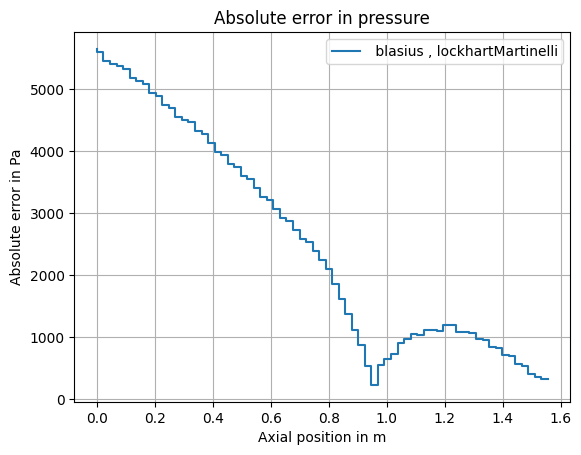

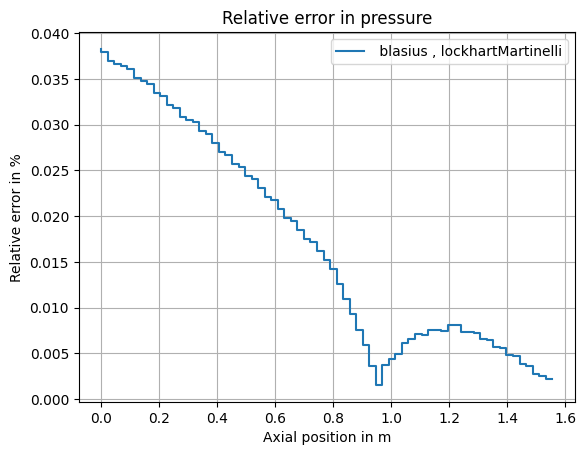

Mean relative error in pressure: 0.017371392286068696, max relative error in pressure 0.038287172812130024 for blasius, lockhartMartinelli
Umixture GeN-Foam: [4.46746    4.46852    4.47021    4.47249    4.47533    4.47873
 4.48268    4.48717    4.49219    4.49775    4.50382    4.51042
 4.51751    4.52511    4.5332     4.54177    4.5508     4.56029
 4.57023    4.58059    4.59137    4.60255    4.61411    4.62603
 4.63829    4.65087    4.66376    4.67692    4.69033    4.70397
 4.71781    4.73183    4.74599    4.76027    4.77773135 4.80355931
 4.83871136 4.88167348 4.9312895  4.98706221 5.04822745 5.11409346
 5.1839926  5.25716583 5.33254183 5.40921287 5.48679472 5.56507561
 5.64380072 5.72270629 5.80151985 5.879898   5.95749305 6.03395386
 6.10888889 6.18194254 6.25272889 6.32088096 6.38680188 6.45014784
 6.50993716 6.5654289  6.61616217 6.6617725  6.70196543 6.73652055
 6.76518712 6.78750729 6.80306512 6.81151385]
zlist Plotter: [0.         0.02253623 0.04507246 0.0676087  0.09014493 0.1

In [43]:
plotter = GFPlotter(caseMerge, rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\PSBT_MPHYS_Q1', "PSBT_MPHYS_Q1")
plotter.plotComparison()
plotter.computeErrors()
plotter.plotErrorsPressure()
#plotter.plotCase()
print(f'Umixture GeN-Foam: {plotter.U_mixture}')
print(f'zlist Plotter: {plotter.zList}')
print(f'len zListplotter: {len(plotter.zList)}')
print(f'zList convection: {case0.convection_sol.z_mesh}')
print(f'len z list convection {len(case0.convection_sol.z_mesh)}')
#print(f'rhoua: {plotter.rhoUA}')  
print(f'rhoL GeN-Foam: {case0.convection_sol.rhoL[-1]}')
print(f'rhoG GeN-Foam: {case0.convection_sol.rhoG[-1]}')
print(f'rho GeN-Foam: {case0.convection_sol.rho[-1]}')

In [44]:
print(f'volume_fracion_fuel: {(fuelRadius ** 2) / ( cladRadius ** 2)}')
print(f'volume_fracion_clad: {(np.pi *cladRadius ** 2) / waterRadius ** 2}')
q = [flowArea * Qfiss1[i] / (np.pi * fuelRadius ** 2) for i in range(len(Qfiss1))]
print(Qfiss1)
for i in range(len(Qfiss1)):
    print(q[i])

volume_fracion_fuel: 0.32590017062773124
volume_fracion_clad: 0.3982265958849156
[159486902.25509876, 301356165.15256023, 431598754.3228657, 555195278.3907946, 674586908.093193, 790911781.930156, 904639215.1319635, 1015899814.2435012, 1124654028.5578709, 1230779934.8432798, 1334114572.2923572, 1434482847.2492993, 1531706335.472457, 1625608396.962607, 1716017625.4982636, 1802766897.0397503, 1885707405.7695413, 1964692011.1630256, 2039585110.796542, 2110258239.2161028, 2176605412.4221807, 2238560256.5968833, 2295973371.175193, 2348761491.5110073, 2396837784.4734035, 2440137303.6384153, 2478595816.2790623, 2512159557.2238245, 2540779995.079011, 2564421444.996292, 2583050363.2182007, 2596650572.6135316, 2605193763.2025976, 2608672322.2177553, 2607081491.6792397, 2600414848.314314, 2588663114.06245, 2571813204.4792604, 2549819442.9588456, 2522568113.784567, 2489808947.2201276, 2451016900.197107, 2405148071.9523845, 2350131313.8888817, 2279856666.2756615, 2202476689.562075, 2123999998.509807